# Лабораторная работа: Рекомендательные системы

## Теоретическая часть

### 1. Суть задачи рекомендательных систем
Рекомендательные системы – это алгоритмы, которые анализируют поведение пользователей и предлагают персонализированные рекомендации товаров, фильмов, музыки и других объектов. Основная цель – предсказать предпочтения пользователей на основе имеющихся данных о взаимодействиях.


### 2. Метод коллаборативной фильтрации
Коллаборативная фильтрация (Collaborative Filtering, CF) – это метод рекомендаций, основанный на анализе поведения пользователей. Он работает на основе предположения, что пользователи с похожими предпочтениями в прошлом будут делать схожий выбор в будущем.

Существует два основных подхода:
1. **User-based CF** – рекомендации строятся на основе сходства пользователей.
2. **Item-based CF** – рекомендации строятся на основе сходства объектов.

### 3. Латентные факторные модели (Matrix Factorization)
Коллаборативная фильтрация может быть реализована через матричное разложение. Пусть у нас есть матрица взаимодействий пользователей и объектов R, где $( R_{u,i} )$ – оценка пользователя ( u ) для объекта ( i ). Тогда разложение можно представить в виде:
$$
R \approx U \cdot V^T
$$
где:
- ( U ) – матрица эмбеддингов пользователей,
- ( V ) – матрица эмбеддингов объектов.

Предсказание рейтинга рассчитывается как:
$$
\hat{R}_{u,i} = U_u \cdot V_i^T
$$

В данной лабораторной работе предполагается использование **нейросетевого метода**, который обучает эмбеддинги пользователей и объектов с помощью полносвязных слоев. Входные данные – индексы пользователей и объектов, которые преобразуются в векторные представления, а затем подаются на вход нейросети.


## Практическая часть
В данной работе вам предлагается реализовать рекомендательную систему на основе метода коллаборативной фильтрации, используя нейросетевую модель. Вы должны:
1. Подготовить данные: загрузить свой датасет (например, рейтинг фильмов, товаров, книг и т. д.).
2. Разбить данные на тренировочный и тестовый наборы.
3. Обучить модель, используя эмбеддинги пользователей и объектов.
4. Оценить качество модели на тестовом наборе.
5. Вывести список рекомендаций для выбранного пользователя.

In [107]:
# Импорты
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Определяем устройство (используем GPU, если доступно)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [108]:
df = pd.read_csv("Netflix_Dataset_Rating.csv")
df = df.sample(n=10000, random_state=42)

df = df.rename(columns={
    "User_ID": "user_id",
    "Movie_ID": "item_id",
    "Rating": "rating"
})

In [109]:

user_ids = df['user_id'].unique()
item_ids = df['item_id'].unique()

user_map = {id_: idx for idx, id_ in enumerate(user_ids)}
item_map = {id_: idx for idx, id_ in enumerate(item_ids)}

reverse_user_map = {v: k for k, v in user_map.items()}
reverse_item_map = {v: k for k, v in item_map.items()}

df['user_id'] = df['user_id'].map(user_map)
df['item_id'] = df['item_id'].map(item_map)

In [110]:
# Определяем датасет PyTorch
class RatingsDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user_id'].values, dtype=torch.long)
        self.items = torch.tensor(df['item_id'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.ratings)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

In [111]:
# Определяем нейросетевую модель для коллаборативной фильтрации
class RecommenderNN(nn.Module):
    def __init__(self, num_users, num_items, embedding_dim=32):
        super(RecommenderNN, self).__init__()
        # Эмбеддинги пользователей и фильмов
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.item_embedding = nn.Embedding(num_items, embedding_dim)

        # Полносвязные слои для предсказания рейтинга
        self.fc_layers = nn.Sequential(
            nn.Linear(embedding_dim * 2, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, user, item):
        # Получаем эмбеддинги пользователя и фильма
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)

        # Объединяем эмбеддинги
        x = torch.cat([user_emb, item_emb], dim=1)

        # Пропускаем через полносвязные слои
        return self.fc_layers(x).squeeze()

In [112]:
# Определяем количество пользователей и фильмов
num_users = df['user_id'].nunique()
num_items = df['item_id'].nunique()


In [113]:
# Создаём датасеты и загрузчики данных
dataset = RatingsDataset(df)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)
test_loader = DataLoader(test_dataset, batch_size=64)

In [114]:
from sklearn.metrics import mean_absolute_error
import numpy as np

def train_model(embedding_dim=16,
                learning_rate=0.005,
                weight_decay=1e-5,
                epochs=15):

    model = RecommenderNN(num_users, num_items, embedding_dim).to(device)

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    criterion = nn.MSELoss()

    train_losses = []
    val_losses = []

    train_mae_list = []
    val_mae_list = []

    for epoch in range(epochs):


        model.train()
        total_train_loss = 0

        train_preds = []
        train_targets = []

        for users, items, ratings in train_loader:
            users, items, ratings = users.to(device), items.to(device), ratings.to(device)

            optimizer.zero_grad()
            predictions = model(users, items)
            loss = criterion(predictions, ratings)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

            train_preds.extend(predictions.detach().cpu().numpy())
            train_targets.extend(ratings.detach().cpu().numpy())

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        train_mae = mean_absolute_error(train_targets, train_preds)
        train_mae_list.append(train_mae)


        model.eval()
        total_val_loss = 0

        val_preds = []
        val_targets = []

        with torch.no_grad():
            for users, items, ratings in val_loader:
                users, items, ratings = users.to(device), items.to(device), ratings.to(device)
                predictions = model(users, items)
                loss = criterion(predictions, ratings)

                total_val_loss += loss.item()

                val_preds.extend(predictions.cpu().numpy())
                val_targets.extend(ratings.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        val_mae = mean_absolute_error(val_targets, val_preds)
        val_mae_list.append(val_mae)

        print(f"Epoch {epoch+1}: "
              f"Train Loss={avg_train_loss:.4f}, "
              f"Val Loss={avg_val_loss:.4f}, "
              f"Train MAE={train_mae:.4f}, "
              f"Val MAE={val_mae:.4f}")

    return model, train_losses, val_losses, train_mae_list, val_mae_list

In [115]:
embedding_dims = [16, 32]
learning_rates = [0.005, 0.001]
weight_decays = [1e-5, 1e-4]

results = {}

for emb_dim in embedding_dims:
    for lr in learning_rates:
        for wd in weight_decays:

            print(f"\n===== emb_dim={emb_dim}, lr={lr}, weight_decay={wd} =====")

            model, train_losses, val_losses, train_mae, val_mae = train_model(
                embedding_dim=emb_dim,
                learning_rate=lr,
                weight_decay=wd,
                epochs=15
            )

            best_val = min(val_losses)

            key = (emb_dim, lr, wd)

            results[key] = {
                "model": model,
                "train_losses": train_losses,
                "val_losses": val_losses,
                "train_mae": train_mae,
                "val_mae": val_mae,
                "best_val_loss": min(val_losses)
            }




===== emb_dim=16, lr=0.005, weight_decay=1e-05 =====
Epoch 1: Train Loss=1.8112, Val Loss=1.3033, Train MAE=1.0520, Val MAE=0.9088
Epoch 2: Train Loss=1.0932, Val Loss=1.3095, Train MAE=0.8365, Val MAE=0.9286
Epoch 3: Train Loss=0.9375, Val Loss=1.3388, Train MAE=0.7642, Val MAE=0.9362
Epoch 4: Train Loss=0.7985, Val Loss=1.5699, Train MAE=0.6914, Val MAE=1.0234
Epoch 5: Train Loss=0.6297, Val Loss=1.7645, Train MAE=0.5946, Val MAE=1.0961
Epoch 6: Train Loss=0.4623, Val Loss=2.0303, Train MAE=0.4989, Val MAE=1.1807
Epoch 7: Train Loss=0.3106, Val Loss=2.3726, Train MAE=0.3987, Val MAE=1.2900
Epoch 8: Train Loss=0.1927, Val Loss=2.5129, Train MAE=0.3113, Val MAE=1.3296
Epoch 9: Train Loss=0.1117, Val Loss=2.5782, Train MAE=0.2325, Val MAE=1.3402
Epoch 10: Train Loss=0.0675, Val Loss=2.7123, Train MAE=0.1835, Val MAE=1.3820
Epoch 11: Train Loss=0.0454, Val Loss=2.7541, Train MAE=0.1555, Val MAE=1.3910
Epoch 12: Train Loss=0.0341, Val Loss=2.7670, Train MAE=0.1369, Val MAE=1.3927
Epoch 1

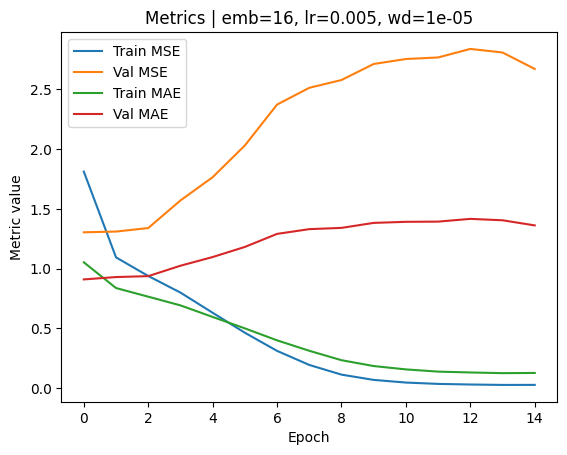

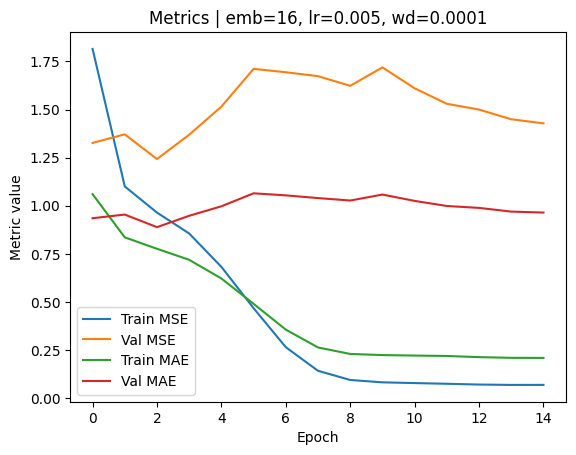

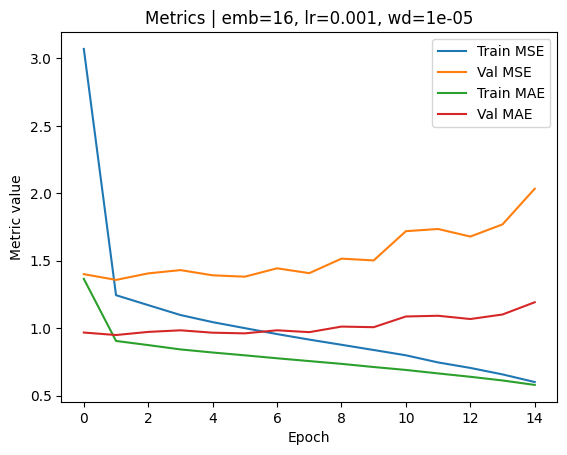

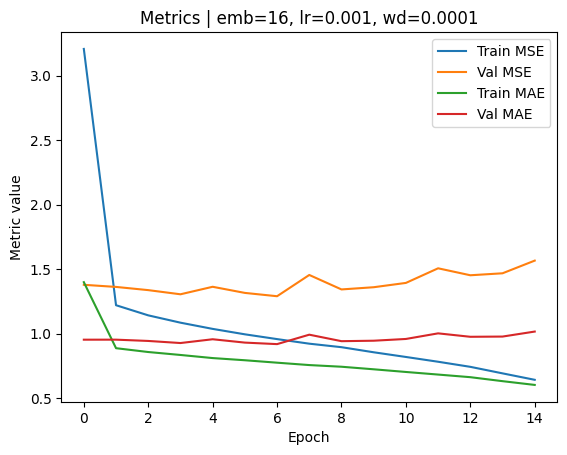

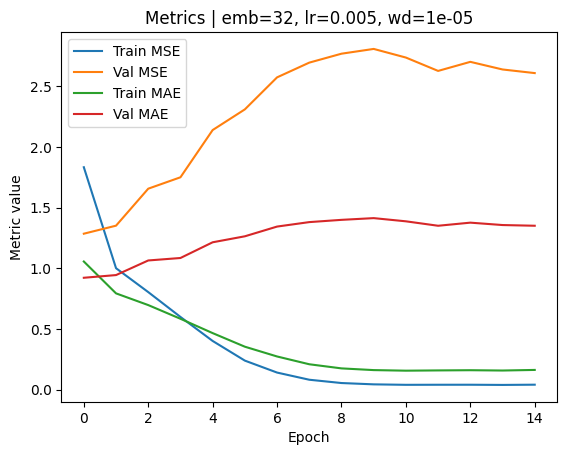

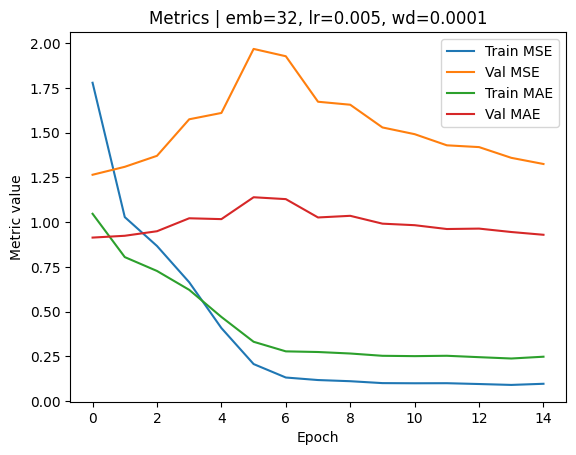

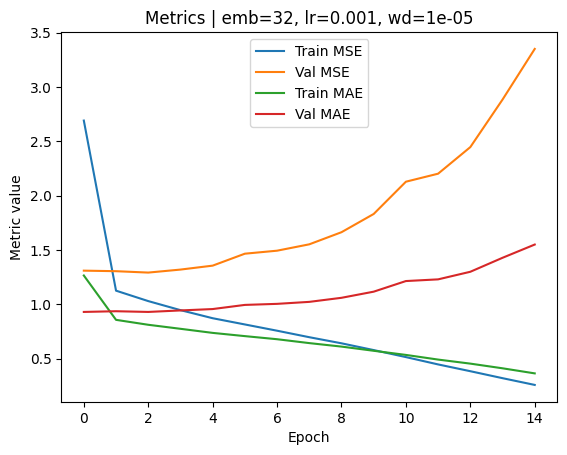

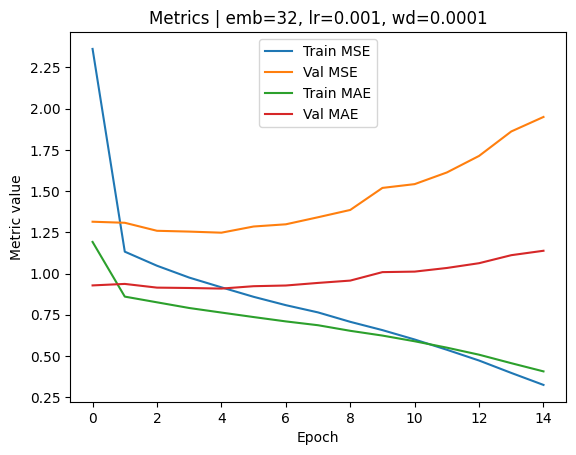

In [116]:
import matplotlib.pyplot as plt

for config, data in results.items():
    emb_dim, lr, wd = config

    plt.figure()

    plt.plot(data["train_losses"], label="Train MSE")
    plt.plot(data["val_losses"], label="Val MSE")

    plt.plot(data["train_mae"], label="Train MAE")
    plt.plot(data["val_mae"], label="Val MAE")

    plt.title(f"Metrics | emb={emb_dim}, lr={lr}, wd={wd}")
    plt.xlabel("Epoch")
    plt.ylabel("Metric value")
    plt.legend()
    plt.show()

Во всех экспериментах наблюдается:

устойчивое снижение Train Loss и Train MAE,

при этом поведение Validation Loss и Validation MAE существенно зависит от выбранных гиперпараметров.

Это говорит о том, что модель успешно минимизирует ошибку на обучающей выборке, однако её способность к обобщению определяется настройкой learning_rate и weight_decay.

1. Влияние learning rate 
1) lr = 0.005 

    При высоком learning rate:

    Train Loss быстро падает почти к нулю.

    Validation Loss после 2–4 эпох начинает резко расти.

    Validation MAE увеличивается до 1.4–1.5.

    Это классическое переобучение:

    модель быстро запоминает тренировочные данные и теряет обобщающую способность.

    Особенно ярко это видно для:

    emb_dim=16, weight_decay=1e-5

    emb_dim=32, weight_decay=1e-5

2) lr = 0.001

    При снижении learning rate:

    обучение становится более плавным,

    Validation Loss колеблется значительно меньше, рост ошибки происходит позже.

    Это указывает на более стабильную сходимость и лучшую генерализацию.

2. Влияние регуляризации (weight_decay)
1) weight_decay = 1e-5

    Регуляризация слабая.

    Модель склонна к быстрому переобучению.

    Validation Loss растёт сильнее.

2) weight_decay = 1e-4

    Переобучение заметно уменьшается.

    Разрыв между train и validation сокращается.

    Validation MAE становится стабильнее.

    Например:

    emb_dim=16, lr=0.005

    weight_decay=1e-5 → Val MAE ≈ 1.45

    weight_decay=1e-4 → Val MAE ≈ 0.96–1.00

    Регуляризация существенно улучшила обобщающую способность.

3. Влияние embedding_dim
1) emb_dim = 16

    Показал более стабильные результаты.

    При корректной регуляризации (wd=1e-4, lr=0.005):

    Validation Loss ≈ 1.35–1.44

    Validation MAE ≈ 0.96–1.00

2) emb_dim = 32

    При высоком lr наблюдается более сильное переобучение.

    Однако при сочетании:

    lr = 0.001

    weight_decay = 1e-4

    Validation MAE достигает ≈ 0.93–0.95 (одни из лучших значений).

    Это говорит о том, что увеличение размерности работает только при адекватной регуляризации.

5. Лучшая конфигурация

Наиболее устойчивые результаты демонстрирует:

emb_dim = 32
lr = 0.001
weight_decay = 1e-4

Validation MAE ≈ 0.93
Validation Loss ≈ 1.33–1.34

Ошибка менее 1 рейтингового балла в среднем.

In [117]:
best_embedding = min(results, key=lambda x: results[x]["best_val_loss"])
best_model = results[best_embedding]["model"]

print(f"\nBest embedding_dim based on validation: {best_embedding}")
print(f"Best validation loss: {results[best_embedding]['best_val_loss']:.4f}")

criterion = nn.MSELoss()
best_model.eval()

total_test_loss = 0

with torch.no_grad():
    for users, items, ratings in test_loader:
        users, items, ratings = users.to(device), items.to(device), ratings.to(device)
        predictions = best_model(users, items)
        loss = criterion(predictions, ratings)
        total_test_loss += loss.item()

avg_test_loss = total_test_loss / len(test_loader)

print(f"\nFinal Test Loss: {avg_test_loss:.4f}")


Best embedding_dim based on validation: (16, 0.005, 0.0001)
Best validation loss: 1.2427

Final Test Loss: 1.4326


In [118]:
def recommend_top_n(model, user_id, df, num_items, N=5):
    model.eval()

    all_items = set(range(num_items))

    interacted_items = set(df[df["user_id"] == user_id]["item_id"].values)

    candidate_items = list(all_items - interacted_items)

    if len(candidate_items) == 0:
        print("No items left to recommend")
        return []

    user_tensor = torch.tensor([user_id] * len(candidate_items), dtype=torch.long).to(device)
    item_tensor = torch.tensor(candidate_items, dtype=torch.long).to(device)

    with torch.no_grad():
        predictions = model(user_tensor, item_tensor)

    predictions = predictions.cpu().numpy()

    top_indices = predictions.argsort()[-N:][::-1]

    top_items = [candidate_items[i] for i in top_indices]

    return top_items

In [119]:
user_id = np.random.choice(df["user_id"].unique())
top_items = recommend_top_n(model, user_id, df, num_items, N=5)

print(f"Recommendations for user {reverse_user_map[user_id]}:")
for item in top_items:
    print(f"Movie ID: {reverse_item_map[item]}")

Recommendations for user 744247:
Movie ID: 2782
Movie ID: 3769
Movie ID: 2430
Movie ID: 3444
Movie ID: 2172
